# TCRemPNet — public VDJdb evaluation (positives-only) — **PLAIN**

Минимальный ноутбук без “статусов” и без защитных проверок.  
Если что-то не так — пусть падает с ошибкой, чтобы сразу видно было где.

Метрики (positives-only):
- **TP**: public клонотип попал в кластер (`cluster_id` не NA)
- **FN**: public клонотип не попал в кластер
- `recall_public = TP/(TP+FN)`
- `public_fraction_in_clustered = TP/n_clustered` (прокси “purity”)


In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Config


In [3]:
EPITOPES_ALPHA = [
  "GILGFVFTL",
  "YLQPRTFLL",
  "GLCTLVAML",
  "NLVPMVATV",
  # "RAKFKQII",
  # "LLWNGPMAV",
  # "TTDPSFLGRY",
  # "SPRWYFYYL",
]

EPITOPES_BETA = [
  "GILGFVFTL",
  # "RAKFKQII",
  "GLCTLVAML",
  "NLVPMVATV",
  "YLQPRTFLL",
  # "KRWIILGLNK",
  "YVLDHLIVV",
]

EPITOPES_COMMON = sorted(set(EPITOPES_ALPHA) & set(EPITOPES_BETA))
EPITOPES_COMMON


['GILGFVFTL', 'GLCTLVAML', 'NLVPMVATV', 'YLQPRTFLL']

In [4]:
BASE_VDJDB = Path("/projects/immunestatus/vdjdb")
TCR_EMP_DIR = BASE_VDJDB / "tcremp"

PUBLIC_TRA_TSV = Path("../../data/vdjdb_public_TRA_minStudies2.tsv")
PUBLIC_TRB_TSV = Path("../../data/vdjdb_public_TRB_minStudies2.tsv")

OUTDIR = Path("../../data/metrics_multi_epitope_publicGT_out")
OUTDIR.mkdir(parents=True, exist_ok=True)

# Your folder layout:
# /projects/immunestatus/vdjdb/tcrempnet_{EPITOPE}_{tra|trb}/...
GRID_ROOTS = {}
for ep in EPITOPES_ALPHA:
    GRID_ROOTS[("tra", ep)] = BASE_VDJDB / f"tcrempnet_{ep}_tra"
for ep in EPITOPES_BETA:
    GRID_ROOTS[("trb", ep)] = BASE_VDJDB / f"tcrempnet_{ep}_trb"

len(GRID_ROOTS)


9

## Helpers


In [5]:
def trim_allele(s: pd.Series) -> pd.Series:
    return s.astype("string").str.replace(r"\*.*$", "", regex=True)


def default_prefix(chain: str, epitope: str) -> str:
    chain = chain.lower()
    pref = "tra" if chain == "tra" else "trb"
    return f"{pref}_vdjdb_{epitope}"


def default_representations_tsv(chain: str, epitope: str) -> Path:
    pref = default_prefix(chain, epitope)
    return TCR_EMP_DIR / f"{pref}_tcremp_representations.tsv"


## Public TP lists loader (fixed columns)


In [6]:
def load_public_truth(epitope: str, chain: str) -> pd.DataFrame:
    chain = chain.lower()
    if chain == "tra":
        path = PUBLIC_TRA_TSV
        cdr3_col, v_col, j_col = "cdr3_alpha", "v_alpha", "j_alpha"
        want_chain = "alpha"
    else:
        path = PUBLIC_TRB_TSV
        cdr3_col, v_col, j_col = "cdr3_beta", "v_beta", "j_beta"
        want_chain = "beta"

    pub = pd.read_csv(path, sep="\t")
    if "chain" in pub.columns:
        pub = pub[pub["chain"] == want_chain]
    pub = pub[pub["epitope"] == epitope]

    out = (
        pub[["epitope", cdr3_col, v_col, j_col]]
        .rename(columns={cdr3_col: "cdr3aa", v_col: "v", j_col: "j"})
        .assign(
            cdr3aa=lambda d: d["cdr3aa"].astype("string"),
            v=lambda d: trim_allele(d["v"]),
            j=lambda d: trim_allele(d["j"]),
        )
        .dropna(subset=["cdr3aa", "v", "j"])
        .drop_duplicates(["cdr3aa", "v", "j"])
        .reset_index(drop=True)
    )
    return out


## Hyperparams from path (as-is)


In [7]:
def parse_params_from_relpath(run_dir: Path, root: Path) -> dict:
    rel = run_dir.relative_to(root)
    parts = [p for p in rel.parts if p and p != "."]

    params = {"relpath": str(rel), "tags": []}

    def set_if_none(key, val):
        if params.get(key) is None:
            params[key] = val

    for part in parts:
        m = re.fullmatch(r"kn_(\d+)", part)
        if m:
            set_if_none("kn", int(m.group(1)))
            continue

        tokens = part.split("__") if "__" in part else [part]
        for tok in tokens:
            m = re.fullmatch(r"ms_(\d+)", tok)
            if m:
                set_if_none("ms", int(m.group(1)))
                continue

            m = re.fullmatch(r"eps_([A-Za-z]+)", tok)
            if m:
                set_if_none("eps_mode", m.group(1))
                continue

            m = re.fullmatch(r"eps_([0-9]*\.?[0-9]+)", tok)
            if m:
                set_if_none("eps", float(m.group(1)))
                continue

            m = re.fullmatch(r"([A-Za-z]+)_([0-9]*\.?[0-9]+)", tok)
            if m:
                k, v = m.group(1), m.group(2)
                val = float(v) if "." in v else int(v)
                if params.get(k) is None:
                    params[k] = val
                else:
                    params["tags"].append(tok)
                continue

            m = re.fullmatch(r"([A-Za-z]+)_([A-Za-z][A-Za-z0-9\-]*)", tok)
            if m:
                k, v = m.group(1), m.group(2)
                if params.get(k) is None:
                    params[k] = v
                else:
                    params["tags"].append(tok)
                continue

            params["tags"].append(tok)

    params["tags"] = "__".join([t for t in params["tags"] if t])
    return params


## Run discovery + positives-only metrics


In [8]:
def compute_public_metrics_for_run(clonotypes_path: Path, public_df: pd.DataFrame, chain: str) -> dict:
    chain = chain.lower()

    enr = pd.read_csv(clonotypes_path, sep="\t")
    enr = enr[enr["source"] == "sample"].copy()

    # IMPORTANT: подставь здесь реальные колонки из enriched файла
    # (я ставлю “ожидаемые” по твоим representations: cdr3aa_alpha/beta + v_* + j_*)
    if chain == "tra":
        cdr3_col, v_col, j_col = "cdr3aa_alpha", "v_alpha", "j_alpha"
    else:
        cdr3_col, v_col, j_col = "cdr3aa_beta", "v_beta", "j_beta"

    enr["_cdr3aa"] = enr[cdr3_col].astype("string")
    enr["_v"] = trim_allele(enr[v_col].astype("string"))
    enr["_j"] = trim_allele(enr[j_col].astype("string"))

    # set всех “кластеризованных” клонов (enriched)
    enriched_set = set(zip(enr["_cdr3aa"], enr["_v"], enr["_j"]))

    pub = public_df.copy()
    pub["_cdr3aa"] = pub["cdr3aa"].astype("string")
    pub["_v"] = trim_allele(pub["v"].astype("string"))
    pub["_j"] = trim_allele(pub["j"].astype("string"))

    pub["in_enriched"] = list(zip(pub["_cdr3aa"], pub["_v"], pub["_j"]))
    pub["in_enriched"] = pub["in_enriched"].apply(lambda t: t in enriched_set)

    TP = int(pub["in_enriched"].sum())
    FN = int((~pub["in_enriched"]).sum())

    n_public = int(pub.shape[0])
    n_clustered = int(len(enriched_set))  # enriched sample size (unique by cdr3/v/j)
    recall_public = TP / (TP + FN) if (TP + FN) else np.nan
    public_fraction_in_clustered = TP / n_clustered if n_clustered else np.nan

    return {
        "TP": TP,
        "FN": FN,
        "n_public": n_public,
        "n_clustered": n_clustered,
        "recall_public": recall_public,
        "public_fraction_in_clustered": public_fraction_in_clustered,
    }

In [10]:
from pathlib import Path

def iter_run_dirs_for_epitope(chain: str, epitope: str):
    root = GRID_ROOTS[(chain.lower(), epitope)]
    run_dirs = sorted({p.parent for p in root.rglob("*_enriched_clonotypes_tcremp.tsv")})
    return root, run_dirs

## Collect all metrics (plain)


In [13]:
def collect_metrics_for_chain_epitopes(chain: str, epitopes: list[str]) -> pd.DataFrame:
    chain = chain.lower()
    rows = []

    for ep in epitopes:
        print(ep)
        rep_path = default_representations_tsv(chain, ep)
        public_df = load_public_truth(ep, chain)
        root, run_dirs = iter_run_dirs_for_epitope(chain, ep)
        print(len(run_dirs))
        
        for run_dir in run_dirs:
            clonotypes_path = next(run_dir.glob("*_enriched_clonotypes_tcremp.tsv"))
            parsed = parse_params_from_relpath(run_dir, root)
            m = compute_public_metrics_for_run(clonotypes_path, public_df, chain)
    
            rows.append({
                "chain_req": chain,
                "epitope": ep,
                "run_dir": str(run_dir),
                **parsed,
                **m,
            })

    return pd.DataFrame(rows)


alpha_df = collect_metrics_for_chain_epitopes("tra", EPITOPES_ALPHA)
beta_df  = collect_metrics_for_chain_epitopes("trb", EPITOPES_BETA)
all_metrics = pd.concat([alpha_df, beta_df], ignore_index=True)

all_metrics.shape


GILGFVFTL
122
YLQPRTFLL
124
GLCTLVAML
124
NLVPMVATV
124
GILGFVFTL
121
GLCTLVAML
123
NLVPMVATV
124
YLQPRTFLL
124
YVLDHLIVV
124


(1110, 13)

## Save tables


In [14]:
all_metrics.to_csv(OUTDIR / "all_metrics_publicGT.tsv", sep="\t", index=False)
all_metrics.to_csv(OUTDIR / "all_metrics_publicGT.csv", index=False)

all_metrics.head()


,chain_req,epitope,run_dir,relpath,tags,kn,lr,TP,FN,n_public,n_clustered,recall_public,public_fraction_in_clustered
0,tra,GILGFVFTL,/projects/immunestatus/vdjdb/tcrempnet_GILGFVF...,leiden/kn_100/lr_0.5,leiden,100,0.5,734,136,870,4520,0.843678,0.162389
1,tra,GILGFVFTL,/projects/immunestatus/vdjdb/tcrempnet_GILGFVF...,leiden/kn_100/lr_1.0,leiden,100,1.0,713,157,870,4355,0.819540,0.163720
2,tra,GILGFVFTL,/projects/immunestatus/vdjdb/tcrempnet_GILGFVF...,leiden/kn_100/lr_1.5,leiden,100,1.5,700,170,870,4305,0.804598,0.162602
3,tra,GILGFVFTL,/projects/immunestatus/vdjdb/tcrempnet_GILGFVF...,leiden/kn_100/lr_10.0,leiden,100,10.0,657,213,870,3904,0.755172,0.168289
4,tra,GILGFVFTL,/projects/immunestatus/vdjdb/tcrempnet_GILGFVF...,leiden/kn_100/lr_2.0,leiden,100,2.0,691,179,870,4242,0.794253,0.162895


## Top configs per epitope (by recall_public)


In [15]:
TOP_N = 5

top_by_recall = (
    all_metrics.sort_values(
        ["chain_req", "epitope", "recall_public", "public_fraction_in_clustered"],
        ascending=[True, True, False, False],
    )
    .groupby(["chain_req", "epitope"], as_index=False)
    .head(TOP_N)
)

best_by_recall = (
    all_metrics.sort_values(
        ["chain_req", "epitope", "recall_public", "public_fraction_in_clustered"],
        ascending=[True, True, False, False],
    )
    .groupby(["chain_req", "epitope"], as_index=False)
    .head(1)
)

top_by_recall.to_csv(OUTDIR / f"top_{TOP_N}_by_recall_public.tsv", sep="\t", index=False)
best_by_recall.to_csv(OUTDIR / "best_by_recall_public.tsv", sep="\t", index=False)

best_by_recall


,chain_req,epitope,run_dir,relpath,tags,kn,lr,TP,FN,n_public,n_clustered,recall_public,public_fraction_in_clustered
17,tra,GILGFVFTL,/projects/immunestatus/vdjdb/tcrempnet_GILGFVF...,leiden/kn_150/lr_0.5,leiden,150,0.5,748,122,870,4646,0.859770,0.160999
286,tra,GLCTLVAML,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,leiden/kn_2/lr_10.0,leiden,2,10.0,18,1,19,245,0.947368,0.073469
447,tra,NLVPMVATV,/projects/immunestatus/vdjdb/tcrempnet_NLVPMVA...,leiden/kn_4/lr_10.0,leiden,4,10.0,9,3,12,479,0.750000,0.018789
228,tra,YLQPRTFLL,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,leiden/kn_8/lr_1.5,leiden,8,1.5,45,0,45,325,1.000000,0.138462
495,trb,GILGFVFTL,/projects/immunestatus/vdjdb/tcrempnet_GILGFVF...,leiden/kn_100/lr_1.0,leiden,100,1.0,1103,0,1103,5186,1.000000,0.212688
682,trb,GLCTLVAML,/projects/immunestatus/vdjdb/tcrempnet_GLCTLVA...,leiden/kn_25/lr_2.0,leiden,25,2.0,59,0,59,1053,1.000000,0.056030
789,trb,NLVPMVATV,/projects/immunestatus/vdjdb/tcrempnet_NLVPMVA...,leiden/kn_200/lr_2.0,leiden,200,2.0,56,1,57,3944,0.982456,0.014199
902,trb,YLQPRTFLL,/projects/immunestatus/vdjdb/tcrempnet_YLQPRTF...,leiden/kn_2/lr_10.0,leiden,2,10.0,46,0,46,893,1.000000,0.051512
1058,trb,YVLDHLIVV,/projects/immunestatus/vdjdb/tcrempnet_YVLDHLI...,leiden/kn_25/lr_5.0,leiden,25,5.0,16,4,20,330,0.800000,0.048485


## Heatmap panels (one metric = all epitopes)

Самый простой вариант: **задать оси руками**.


In [16]:
def panel_heatmaps(df: pd.DataFrame, chain: str, epitopes: list[str], value_col: str, x_param: str, y_param: str, ncols: int = 4):
    d = df[(df["chain_req"] == chain) & (df["epitope"].isin(epitopes))].copy()

    x_vals = sorted(d[x_param].dropna().unique())
    y_vals = sorted(d[y_param].dropna().unique())

    mats = []
    for ep in epitopes:
        g = d[d["epitope"] == ep]
        agg = g.groupby([y_param, x_param], as_index=False)[value_col].max()
        piv = agg.pivot(index=y_param, columns=x_param, values=value_col).reindex(index=y_vals, columns=x_vals)
        mats.append(piv.values.astype(float))

    vals = np.concatenate([m[~np.isnan(m)].ravel() for m in mats if np.any(~np.isnan(m))], axis=0)
    vmin = float(np.nanmin(vals)) if vals.size else 0.0
    vmax = float(np.nanmax(vals)) if vals.size else 1.0

    n = len(epitopes)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.6*ncols, 3.2*nrows), squeeze=False)

    im = None
    for i, ep in enumerate(epitopes):
        r, c = divmod(i, ncols)
        ax = axes[r][c]
        im = ax.imshow(mats[i], aspect="auto", vmin=vmin, vmax=vmax)
        ax.set_title(ep)
        ax.set_xlabel(x_param)
        ax.set_ylabel(y_param)
        ax.set_xticks(range(len(x_vals)))
        ax.set_xticklabels([str(x) for x in x_vals], rotation=45, ha="right")
        ax.set_yticks(range(len(y_vals)))
        ax.set_yticklabels([str(y) for y in y_vals])

    for j in range(n, nrows*ncols):
        r, c = divmod(j, ncols)
        axes[r][c].axis("off")

    fig.suptitle(f"{chain.upper()} — {value_col} (X={x_param}, Y={y_param})", y=1.02)
    fig.colorbar(im, ax=axes.ravel().tolist(), anchor=(2.2, 0.5))
    plt.tight_layout()
    plt.show()


/scratch/ipykernel_1832663/2609851177.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


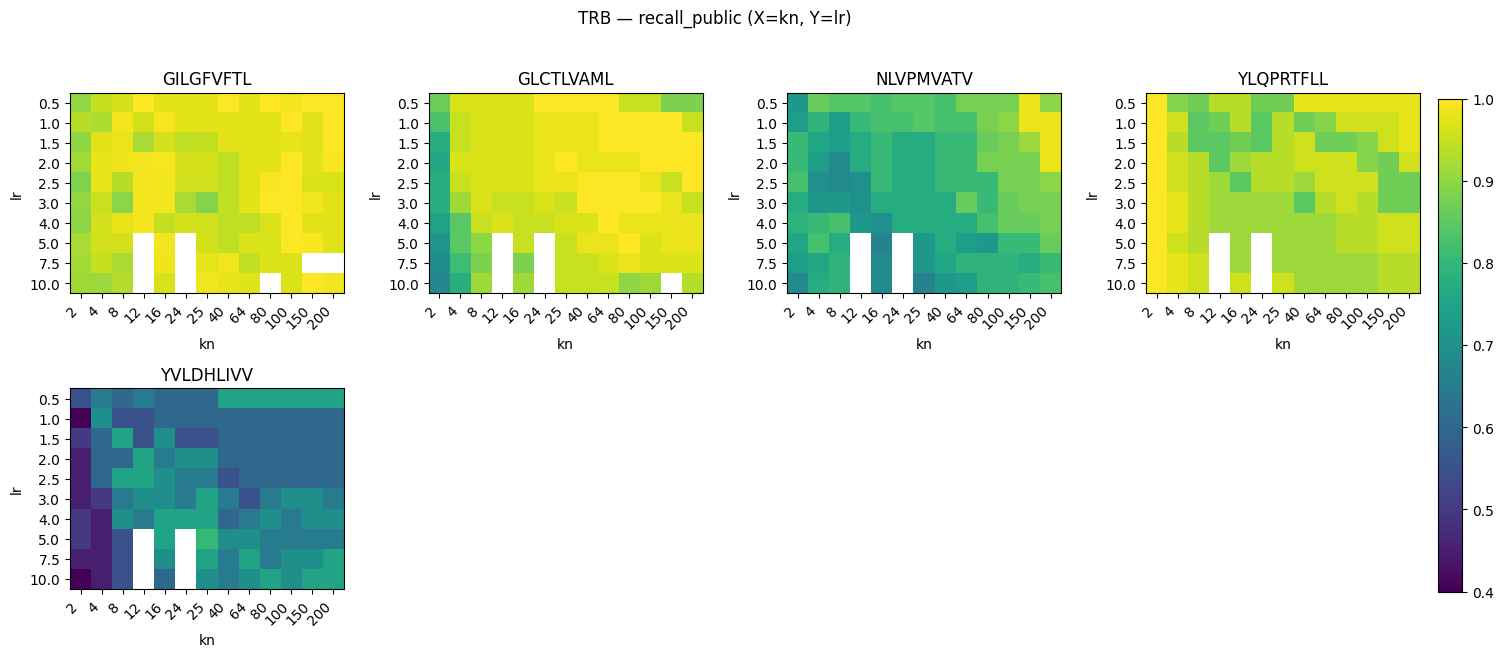

/scratch/ipykernel_1832663/2609851177.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


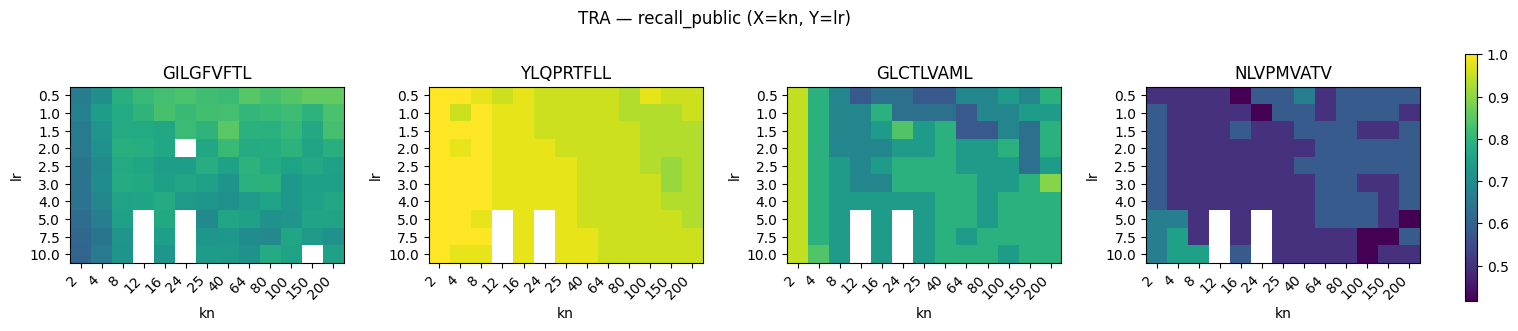

In [17]:
# CHANGE THESE to parameters that exist in your parsed paths
X_PARAM = "kn"
Y_PARAM = "lr"   # e.g. lr_2.5 in path

panel_heatmaps(all_metrics, "trb", EPITOPES_BETA, "recall_public", X_PARAM, Y_PARAM, ncols=4)

panel_heatmaps(all_metrics, "tra", EPITOPES_ALPHA, "recall_public", X_PARAM, Y_PARAM, ncols=4)
